In [1]:
pip install numpy scipy matplotlib

👉 INSTRUCTIONS: Select BOTH 'M1F1-Alaw-AFsp.wav' and 'GLASS.wav' together.


Saving GLASS.wav to GLASS (2).wav
Saving M1F1-Alaw-AFsp.wav to M1F1-Alaw-AFsp (4).wav

✅ DSP ANALYSIS COMPLETE
📊 SNR Before Filtering: -1.52 dB
📊 SNR After Filtering:  2.63 dB
🚀 Total SNR Gain:      4.15 dB



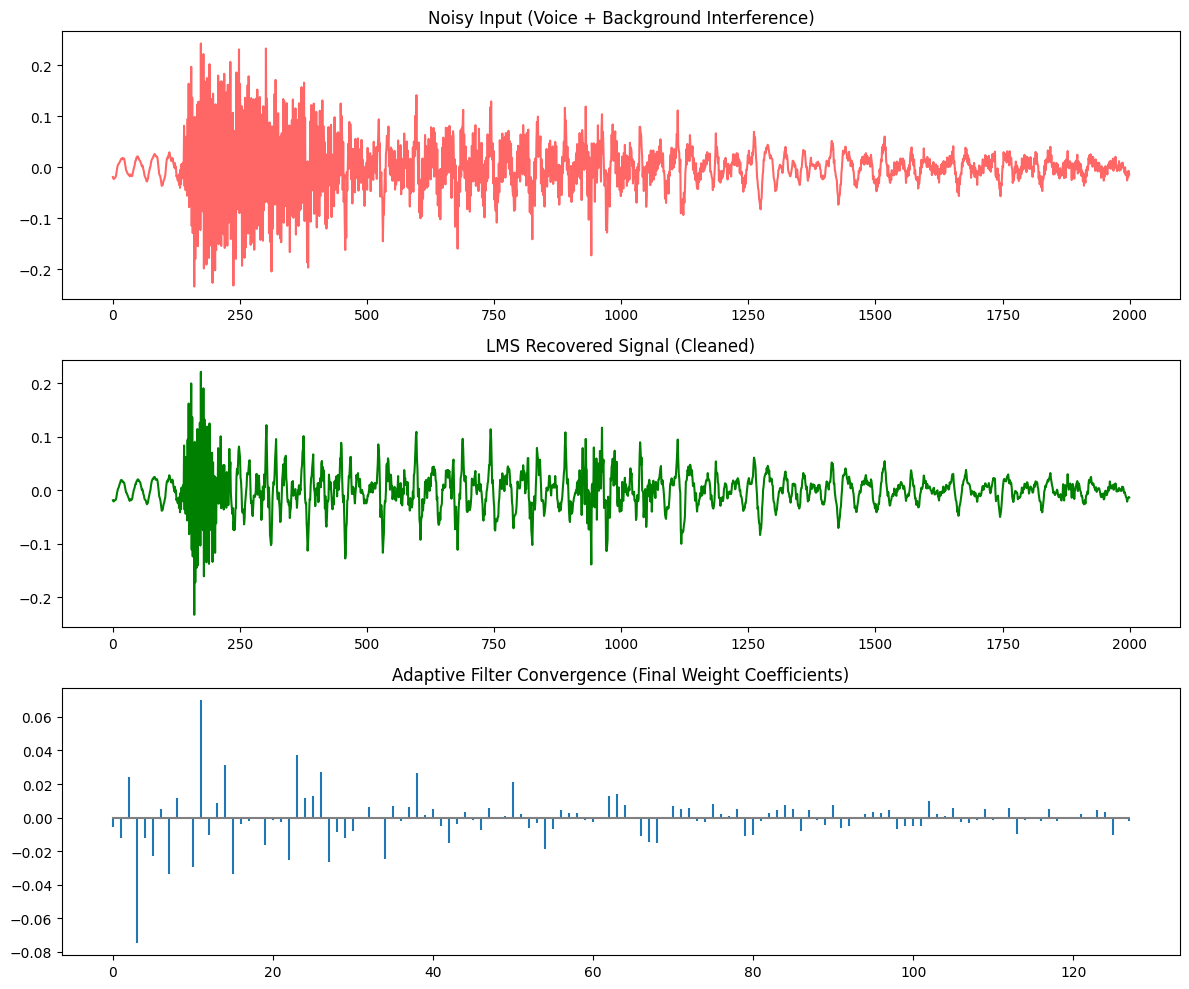

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

💾 Cleaned audio downloaded as 'Final_Project_Output.wav'


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from google.colab import files
import io

# --- 1. CORE DSP FUNCTIONS ---
def lms_adaptive_filter(reference_noise, primary_signal, mu=0.01, order=128):
    """
    Least Mean Squares (LMS) Algorithm.
    Updates weights to minimize the error between prediction and primary signal.
    """
    n = len(primary_signal)
    w = np.zeros(order)              # Initial weights (taps)
    output_clean = np.zeros(n)       # The recovered signal (Error)

    for i in range(order, n):
        # Local window of reference noise
        x = reference_noise[i-order:i][::-1]

        # Linear prediction of noise in the primary signal
        noise_prediction = np.dot(w, x)

        # Error signal (Desired Clean Signal)
        error = primary_signal[i] - noise_prediction

        # Weight Update (Stochastic Gradient Descent)
        w = w + 2 * mu * error * x

        output_clean[i] = error

    return output_clean, w

def calculate_snr(signal, residual_noise):
    """Calculates Signal-to-Noise Ratio in dB"""
    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(residual_noise ** 2) + 1e-10
    return 10 * np.log10(signal_power / noise_power)

# --- 2. INTERACTIVE FILE HANDLING ---
print("👉 INSTRUCTIONS: Select BOTH 'M1F1-Alaw-AFsp.wav' and 'GLASS.wav' together.")
uploaded = files.upload()
filenames = list(uploaded.keys())

# Identify files dynamically
voice_file = next((f for f in filenames if 'M1F1' in f.upper()), None)
noise_file = next((f for f in filenames if 'GLASS' in f.upper()), None)

# --- 3. SYSTEM EXECUTION ---
if voice_file and noise_file:
    # Load with Librosa to handle telecommunication codecs (A-Law/U-Law)
    voice, fs = librosa.load(io.BytesIO(uploaded[voice_file]), sr=None)
    noise, _ = librosa.load(io.BytesIO(uploaded[noise_file]), sr=fs)

    # Signal Alignment & Simulated Mixing
    length = min(len(voice), len(noise))
    v_clean = voice[:length]
    n_interf = 0.5 * noise[:length]  # Scale noise amplitude
    mic_input = v_clean + n_interf

    # Run Adaptive Filter
    # Parameters: mu (learning rate), order (number of taps)
    recovered, final_weights = lms_adaptive_filter(noise[:length], mic_input, mu=0.01, order=128)

    # Performance Analysis
    snr_before = calculate_snr(v_clean, n_interf)
    snr_after = calculate_snr(v_clean, v_clean - recovered)

    print("\n" + "="*45)
    print(f"✅ DSP ANALYSIS COMPLETE")
    print(f"📊 SNR Before Filtering: {snr_before:.2f} dB")
    print(f"📊 SNR After Filtering:  {snr_after:.2f} dB")
    print(f"🚀 Total SNR Gain:      {snr_after - snr_before:.2f} dB")
    print("="*45 + "\n")

    # Visualization
    plt.figure(figsize=(12, 10))

    plt.subplot(3, 1, 1)
    plt.title("Noisy Input (Voice + Background Interference)")
    plt.plot(mic_input[4000:6000], color='red', alpha=0.6)

    plt.subplot(3, 1, 2)
    plt.title("LMS Recovered Signal (Cleaned)")
    plt.plot(recovered[4000:6000], color='green')

    plt.subplot(3, 1, 3)
    plt.title("Adaptive Filter Convergence (Final Weight Coefficients)")
    plt.stem(final_weights, markerfmt=' ', basefmt="gray")

    plt.tight_layout()
    plt.show()

    # Final Export
    sf.write('Final_Project_Output.wav', recovered, fs)
    files.download('Final_Project_Output.wav')
    print("💾 Cleaned audio downloaded as 'Final_Project_Output.wav'")

else:
    print("❌ ERROR: Both voice and noise files must be uploaded.")

In [20]:
def calculate_snr(signal, noise):
    """Calculates Signal-to-Noise Ratio in dB"""
    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)
    return 10 * np.log10(signal_power / noise_power)